# Clustering with Annealing

This tutorial will cover clustering using Openjij as an example for an application of annealing.

## Overview of Clustering
Assuming $n$ is given externally, we divide the given data into $n$ clusters. Let us consider 2 clusters in this case.

### Clustering Hamiltonian
Clustering can be done by minimizing the following Hamiltonian:

$$
H = - \sum_{i, j} \frac{1}{2}d_{i,j} (1 - \sigma _i \sigma_j)
$$

$i, j$ is the sample number, $d_{i,j}$ is the distance between the two samples, and $\sigma_i=\{-1,1\}$ is a spin variable that indicates which of the two clusters it belongs to.
Each term of this Hamiltonian sum is:

- 0 when $\sigma_i = \sigma_j $
- $d_{i,j}$  when $\sigma_i \neq \sigma_j $

With the negative on the right-hand side of the Hamiltonian, the entire Hamiltonian comes down to the question to choose the pair of $\{\sigma _1, \sigma _2 \ldots \}$ that maximizes the distance between samples belonging to different classes.

## Formulation with JijModeling

Let us formulate the above Hamiltonian using JijModeling.
We define the necessary variables below.
In JijModeling, we cannot directly use spin variables $\sigma_i$, so we rewrite them using binary variables $x_i$ via the relation $\sigma_i = 2x_i - 1$.

In [1]:
import jijmodeling as jm

problem = jm.Problem("Clustering")

d = problem.Float("d", ndim=2)
N = problem.DependentVar("N", d.len_at(0))
x = problem.BinaryVar("x", shape=(N, ))

def sigma(i):
    return 2 * x[i] - 1

Here, `d` is defined as the distance matrix between samples, `N` as the number of samples (automatically determined from the dimension of `d`), and `x` as a binary variable. The correspondence with spin variables $\sigma_i = 2x_i - 1$ is defined as the `sigma` function.

### Hamiltonian

Let us formulate the Hamiltonian above.

In [2]:
problem += -jm.sum(
    jm.product(N, N),
    lambda i, j: d[i, j] * (1 - (sigma(i) * sigma(j))),
)

Let us display the formulated mathematical model in the Jupyter Notebook.

In [3]:
problem

Problem(name="Clustering", sense=MINIMIZE, objective=- sum(set((N, N)).map(lambda ((i, j): Tuple[natural, natural]): d[i, j] * (1 - (2 * x[i] - 1) * (2 * x[j] - 1)))), constraints=[])

## Creating an Instance

Let us artificially generate linearly separable data on a 2D plane.

In [4]:
import numpy as np
import pandas as pd

from scipy.spatial import distance_matrix

data = []
label = []
for i in range(100):
    # Generate random numbers in [0, 1]
    p = np.random.uniform(0, 1)
    # Class 1 when a condition is satisfied, -1 when it is not
    cls = 1 if p > 0.5 else -1
    # Create random numbers that follow a normal distribution centered at a certain coordinate
    data.append(np.random.normal(0, 0.5, 2) + np.array([cls, cls]))
    label.append(cls)
# Format as a DataFrame
df1 = pd.DataFrame(data, columns=["x", "y"], index=range(len(data)))
df1["label"] = label
instance_data = {'d': distance_matrix(df1, df1)}

Let us visualize the generated data.

<Axes: xlabel='x', ylabel='y'>

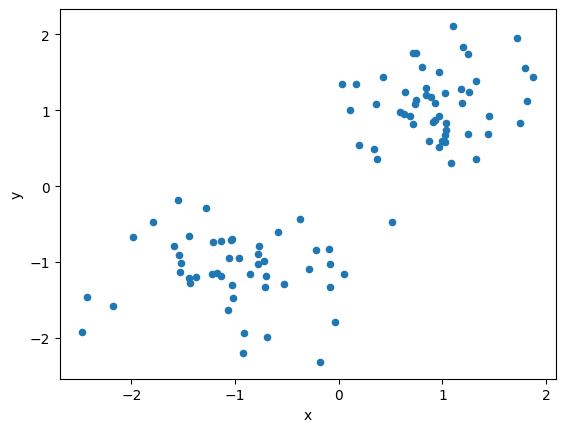

In [5]:
# Visualize dataset
df1.plot(kind='scatter', x="x", y="y")

## Running Optimization with OpenJij

Let us solve the optimization problem using OpenJij's simulated annealing.

In [6]:
from ommx_openjij_adapter import OMMXOpenJijSAAdapter

instance = problem.eval(instance_data)

adapter = OMMXOpenJijSAAdapter(instance)
best_sample = adapter.sample(
    instance, num_reads=100
).best_feasible_unrelaxed

## Visualizing the Solution

Let us visualize the obtained solution.

Text(0, 0.5, 'y')

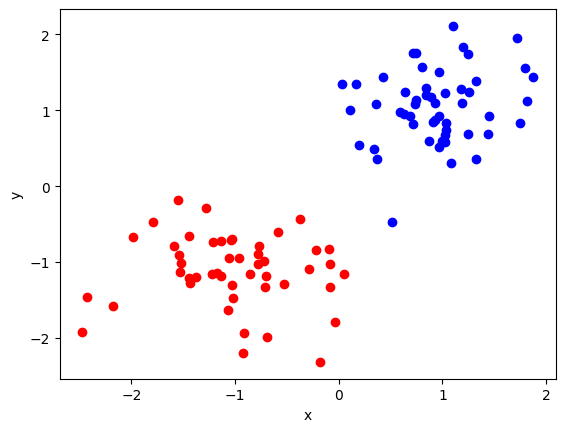

In [7]:
import matplotlib.pyplot as plt

df = best_sample.decision_variables_df
x_indices = set(row["subscripts"][0] for _, row in df.iterrows() if row["name"] == "x" and row["value"] > 0.5)
for idx in range(len(instance_data['d'])):
    color = "b" if idx in x_indices else "r"
    plt.scatter(df1.loc[idx]["x"], df1.loc[idx]["y"], color=color)
plt.xlabel('x')
plt.ylabel('y')

We can see that the data is classified into two classes: red and blue.